# Implementing PCA from Scratch
## Analyzing Real-Time Driver Drowsiness Detection 

**National Higher School of Computer Science — ESI Sidi-Bel-Abbès**  
Data Analysis Course: 2025–2026



---
## Part 1 — Introduction & Data Loading


### 1.1 What is PCA?

Principal Component Analysis (PCA) is an unsupervised dimensionality-reduction technique. It transforms a dataset of potentially correlated features into a smaller set of orthogonal (uncorrelated) variables called **principal components**.

Mathematically, PCA finds the directions (eigenvectors of the covariance matrix) along which the data varies the most (corresponding eigenvalues), and projects the data onto those directions.

**Key mathematical steps:**
1. Center the data: subtract the mean of each feature
2. Compute the covariance matrix: **Σ = (1/n−1) · XᵀX**
3. Perform eigen-decomposition: **Σv = λv**
4. Sort eigenvectors by descending eigenvalue
5. Project data: **Z = X · Vk** (Vk holds top-k eigenvectors)

### 1.2 Project Objective

- Implement PCA **entirely from scratch** using only NumPy
- Apply it to a simulated real-world driver drowsiness detection dataset
- Reduce high-dimensional physiological/behavioral signals to 2 principal components
- Visualize and interpret the structure to discover hidden patterns

In [ ]:

# Task: Import libraries and generate the dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print("Libraries imported successfully.")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully.
NumPy version: 2.0.2
Pandas version: 2.3.3


In [ ]:

# Task: Generate synthetic driver drowsiness dataset

n = 2000
labels_raw = np.random.choice(['Alert', 'Drowsy', 'Micro-sleep'], size=n, p=[0.50, 0.35, 0.15])

def make_group(label, n_samples):
    if label == 'Alert':
        return {
            'PERCLOS': np.random.normal(0.10, 0.03, n_samples).clip(0,1),
            'Blink_Rate_per_min': np.random.normal(18, 3, n_samples).clip(5,40),
            'Blink_Duration_ms': np.random.normal(150, 20, n_samples).clip(80,300),
            'Eye_Aspect_Ratio': np.random.normal(0.35, 0.04, n_samples).clip(0.1,0.6),
            'Yawn_Frequency_per_hr': np.random.normal(3, 1.5, n_samples).clip(0,20),
            'Yawn_Duration_s': np.random.normal(1.5, 0.5, n_samples).clip(0.5,5),
            'Head_Tilt_Angle_deg': np.random.normal(5, 3, n_samples).clip(0,30),
            'Head_Nod_Count': np.random.normal(1, 0.8, n_samples).clip(0,10),
            'Steering_Deviation_deg': np.random.normal(2, 1, n_samples).clip(0,15),
            'Lane_Deviation_cm': np.random.normal(5, 2, n_samples).clip(0,40),
            'Reaction_Time_ms': np.random.normal(250, 40, n_samples).clip(150,600),
            'Heart_Rate_bpm': np.random.normal(78, 8, n_samples).clip(50,110),
            'HRV_ms': np.random.normal(55, 10, n_samples).clip(20,100),
            'Skin_Conductance_uS': np.random.normal(5.0, 1.0, n_samples).clip(1,15),
            'EEG_Alpha_Power': np.random.normal(0.20, 0.05, n_samples).clip(0.05,0.6),
            'EEG_Theta_Power': np.random.normal(0.15, 0.04, n_samples).clip(0.05,0.5),
            'Driving_Duration_hr': np.random.uniform(0, 3, n_samples),
            'Time_of_Day_hr': np.random.choice(list(range(6,22)), n_samples).astype(float),
            'Caffeine_mg': np.random.normal(150, 60, n_samples).clip(0,400),
            'Sleep_Hours_prev_night': np.random.normal(7.5, 0.8, n_samples).clip(3,10),
        }
    elif label == 'Drowsy':
        return {
            'PERCLOS': np.random.normal(0.30, 0.07, n_samples).clip(0,1),
            'Blink_Rate_per_min': np.random.normal(10, 3, n_samples).clip(2,30),
            'Blink_Duration_ms': np.random.normal(230, 35, n_samples).clip(100,500),
            'Eye_Aspect_Ratio': np.random.normal(0.24, 0.05, n_samples).clip(0.05,0.5),
            'Yawn_Frequency_per_hr': np.random.normal(12, 3, n_samples).clip(0,40),
            'Yawn_Duration_s': np.random.normal(3.5, 0.8, n_samples).clip(1,8),
            'Head_Tilt_Angle_deg': np.random.normal(18, 6, n_samples).clip(0,50),
            'Head_Nod_Count': np.random.normal(5, 2, n_samples).clip(0,20),
            'Steering_Deviation_deg': np.random.normal(7, 2.5, n_samples).clip(0,25),
            'Lane_Deviation_cm': np.random.normal(18, 5, n_samples).clip(0,60),
            'Reaction_Time_ms': np.random.normal(420, 60, n_samples).clip(200,900),
            'Heart_Rate_bpm': np.random.normal(68, 7, n_samples).clip(45,100),
            'HRV_ms': np.random.normal(38, 9, n_samples).clip(10,80),
            'Skin_Conductance_uS': np.random.normal(3.5, 0.8, n_samples).clip(0.5,10),
            'EEG_Alpha_Power': np.random.normal(0.38, 0.07, n_samples).clip(0.1,0.8),
            'EEG_Theta_Power': np.random.normal(0.32, 0.07, n_samples).clip(0.1,0.7),
            'Driving_Duration_hr': np.random.uniform(2, 6, n_samples),
            'Time_of_Day_hr': np.random.choice(list(range(0,6))+list(range(14,16)), n_samples).astype(float),
            'Caffeine_mg': np.random.normal(60, 40, n_samples).clip(0,200),
            'Sleep_Hours_prev_night': np.random.normal(5.0, 1.0, n_samples).clip(2,8),
        }
    else:  # Micro-sleep
        return {
            'PERCLOS': np.random.normal(0.55, 0.10, n_samples).clip(0.3,1),
            'Blink_Rate_per_min': np.random.normal(5, 2, n_samples).clip(0,20),
            'Blink_Duration_ms': np.random.normal(350, 50, n_samples).clip(150,700),
            'Eye_Aspect_Ratio': np.random.normal(0.14, 0.04, n_samples).clip(0.02,0.35),
            'Yawn_Frequency_per_hr': np.random.normal(20, 4, n_samples).clip(5,50),
            'Yawn_Duration_s': np.random.normal(5.5, 1.0, n_samples).clip(2,12),
            'Head_Tilt_Angle_deg': np.random.normal(35, 8, n_samples).clip(10,70),
            'Head_Nod_Count': np.random.normal(10, 3, n_samples).clip(2,30),
            'Steering_Deviation_deg': np.random.normal(15, 4, n_samples).clip(3,35),
            'Lane_Deviation_cm': np.random.normal(35, 8, n_samples).clip(10,80),
            'Reaction_Time_ms': np.random.normal(620, 80, n_samples).clip(350,1200),
            'Heart_Rate_bpm': np.random.normal(60, 6, n_samples).clip(40,85),
            'HRV_ms': np.random.normal(25, 6, n_samples).clip(5,60),
            'Skin_Conductance_uS': np.random.normal(2.5, 0.7, n_samples).clip(0.2,7),
            'EEG_Alpha_Power': np.random.normal(0.52, 0.09, n_samples).clip(0.2,0.9),
            'EEG_Theta_Power': np.random.normal(0.50, 0.09, n_samples).clip(0.2,0.9),
            'Driving_Duration_hr': np.random.uniform(4, 9, n_samples),
            'Time_of_Day_hr': np.random.choice(list(range(1,5)), n_samples).astype(float),
            'Caffeine_mg': np.random.normal(20, 20, n_samples).clip(0,100),
            'Sleep_Hours_prev_night': np.random.normal(3.5, 0.8, n_samples).clip(1,6),
        }

rows = []
for label in labels_raw:
    group = make_group(label, 1)
    row = {k: v[0] for k, v in group.items()}
    row['Drowsiness_Level'] = label
    row['Driver_Age'] = np.random.randint(20, 65)
    row['Experience_Years'] = np.random.randint(0, 40)
    row['Vehicle_Speed_kmh'] = np.random.normal(90, 25, 1)[0].clip(20, 160)
    rows.append(row)

df = pd.DataFrame(rows)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2000, 24)


,PERCLOS,Blink_Rate_per_min,Blink_Duration_ms,Eye_Aspect_Ratio,Yawn_Frequency_per_hr,Yawn_Duration_s,Head_Tilt_Angle_deg,Head_Nod_Count,Steering_Deviation_deg,Lane_Deviation_cm,...,EEG_Alpha_Power,EEG_Theta_Power,Driving_Duration_hr,Time_of_Day_hr,Caffeine_mg,Sleep_Hours_prev_night,Drowsiness_Level,Driver_Age,Experience_Years,Vehicle_Speed_kmh
0,0.073661,15.519359,145.470422,0.364695,4.370377,1.098411,9.478066,0.783101,1.978633,3.505577,...,0.203350,0.170638,2.810467,15.0,179.241588,7.944303,Alert,33,36,62.240012
1,0.606706,2.333685,470.739550,0.143200,21.391624,4.691580,32.477881,8.719729,12.832660,40.063694,...,0.533708,0.534153,4.408627,2.0,56.230096,3.310686,Micro-sleep,24,1,118.757263
2,0.221300,11.950571,287.142837,0.226954,14.833473,2.948617,16.185199,3.370072,1.667167,17.817333,...,0.311817,0.352165,3.021973,4.0,72.698877,4.968082,Drowsy,45,1,88.473914
3,0.248490,10.250041,260.844967,0.191328,11.983808,4.330711,21.032545,7.618946,5.579644,8.846158,...,0.417572,0.373577,4.132115,1.0,52.327142,7.019838,Drowsy,21,6,44.240222
4,0.053030,21.893265,200.873358,0.357312,2.858846,1.338930,7.345398,1.454149,3.003498,3.744167,...,0.153874,0.196949,2.991234,15.0,78.659323,7.295798,Alert,46,4,119.684651


In [ ]:

# Task: Initial data exploration

print("=== Dataset Info ===")
print(df.dtypes)
print(f"\nMissing values: {df.isnull().sum().sum()}")
print("\n=== Descriptive Statistics (Numerical) ===")
df.describe().round(2)

=== Dataset Info ===
PERCLOS                   float64
Blink_Rate_per_min        float64
Blink_Duration_ms         float64
Eye_Aspect_Ratio          float64
Yawn_Frequency_per_hr     float64
Yawn_Duration_s           float64
Head_Tilt_Angle_deg       float64
Head_Nod_Count            float64
Steering_Deviation_deg    float64
Lane_Deviation_cm         float64
Reaction_Time_ms          float64
Heart_Rate_bpm            float64
HRV_ms                    float64
Skin_Conductance_uS       float64
EEG_Alpha_Power           float64
EEG_Theta_Power           float64
Driving_Duration_hr       float64
Time_of_Day_hr            float64
Caffeine_mg               float64
Sleep_Hours_prev_night    float64
Drowsiness_Level           object
Driver_Age                  int64
Experience_Years            int64
Vehicle_Speed_kmh         float64
dtype: object

Missing values: 0

=== Descriptive Statistics (Numerical) ===


,PERCLOS,Blink_Rate_per_min,Blink_Duration_ms,Eye_Aspect_Ratio,Yawn_Frequency_per_hr,Yawn_Duration_s,Head_Tilt_Angle_deg,Head_Nod_Count,Steering_Deviation_deg,Lane_Deviation_cm,...,Skin_Conductance_uS,EEG_Alpha_Power,EEG_Theta_Power,Driving_Duration_hr,Time_of_Day_hr,Caffeine_mg,Sleep_Hours_prev_night,Driver_Age,Experience_Years,Vehicle_Speed_kmh
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,...,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,0.24,13.02,208.08,0.28,8.79,2.81,14.19,3.83,5.74,14.23,...,4.14,0.31,0.26,3.16,9.11,100.36,6.01,42.08,19.08,89.93
std,0.17,5.70,75.77,0.09,6.64,1.59,11.96,3.58,4.99,11.62,...,1.32,0.14,0.14,2.12,6.57,72.45,1.76,12.98,11.43,25.78
min,0.00,0.00,86.01,0.04,0.00,0.50,0.00,0.00,0.00,0.00,...,0.50,0.05,0.05,0.01,0.00,0.00,1.29,20.00,0.00,20.00
25%,0.10,8.35,150.71,0.22,3.10,1.50,4.55,1.00,2.02,4.97,...,3.16,0.20,0.15,1.53,3.00,39.79,4.63,31.00,9.00,71.35
50%,0.18,13.30,182.55,0.30,6.29,2.32,9.81,2.31,3.59,9.08,...,4.08,0.28,0.22,2.69,9.00,89.95,6.30,42.00,19.00,90.10
75%,0.34,17.76,250.50,0.35,13.77,3.91,21.83,6.08,8.38,20.87,...,5.09,0.41,0.36,4.67,15.00,150.33,7.47,53.00,29.00,107.82
max,0.82,27.81,486.54,0.47,33.51,7.80,56.04,16.75,27.44,54.61,...,8.50,0.76,0.73,8.98,21.00,368.41,10.00,64.00,39.00,160.00


---
## Part 2 — Data Preprocessing


In [ ]:

# Task: Step 1 — Drop non-informative columns and handle missing values

df_proc = df.copy()

# Keep drowsiness label for visualization later
labels = df_proc['Drowsiness_Level'].values
df_proc = df_proc.drop(columns=['Drowsiness_Level'])

# Handle missing values
before = len(df_proc)
df_proc = df_proc.dropna()
after = len(df_proc)
print(f"Dropped {before - after} rows with missing values. Remaining: {after}")
print(f"Feature shape after cleaning: {df_proc.shape}")

Dropped 0 rows with missing values. Remaining: 2000
Feature shape after cleaning: (2000, 23)


In [ ]:

# Task: Step 2 — Manual z-score standardization (no sklearn)

X = df_proc.values.astype(float)
X = np.nan_to_num(X)

col_means = X.mean(axis=0)
col_stds  = X.std(axis=0, ddof=0)
col_stds_safe = np.where(col_stds == 0, 1, col_stds)

X_scaled = (X - col_means) / col_stds_safe

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Mean of first 5 cols (should be ~0): {X_scaled[:, :5].mean(axis=0).round(6)}")
print(f"Std  of first 5 cols (should be ~1): {X_scaled[:, :5].std(axis=0).round(6)}")

Feature matrix shape: (2000, 23)
Mean of first 5 cols (should be ~0): [ 0. -0. -0. -0.  0.]
Std  of first 5 cols (should be ~1): [1. 1. 1. 1. 1.]


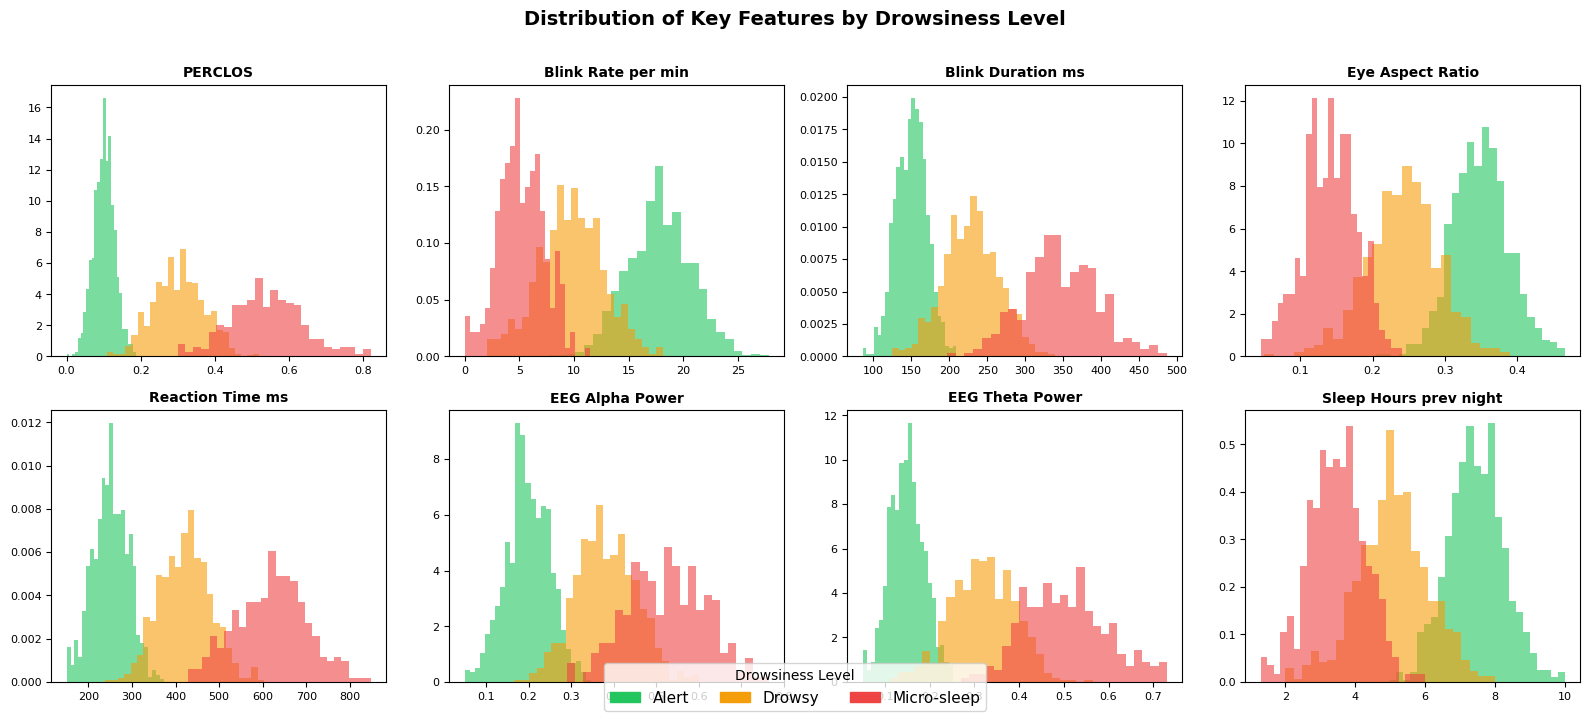

Distribution plot saved.


In [ ]:

# Task: Step 3 — Exploratory Data Analysis (EDA)

num_cols = ['PERCLOS', 'Blink_Rate_per_min', 'Blink_Duration_ms',
            'Eye_Aspect_Ratio', 'Reaction_Time_ms', 'EEG_Alpha_Power',
            'EEG_Theta_Power', 'Sleep_Hours_prev_night']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
palette = {'Alert': '#22C55E', 'Drowsy': '#F59E0B', 'Micro-sleep': '#EF4444'}

for i, col in enumerate(num_cols):
    ax = axes[i // 4][i % 4]
    for lvl, color in palette.items():
        mask = labels == lvl
        ax.hist(df.loc[mask, col], bins=25, alpha=0.6, color=color, label=lvl, density=True)
    ax.set_title(col.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(labelsize=8)

handles = [mpatches.Patch(color=c, label=l) for l, c in palette.items()]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=11, title='Drowsiness Level')
plt.suptitle('Distribution of Key Features by Drowsiness Level', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Distribution plot saved.")

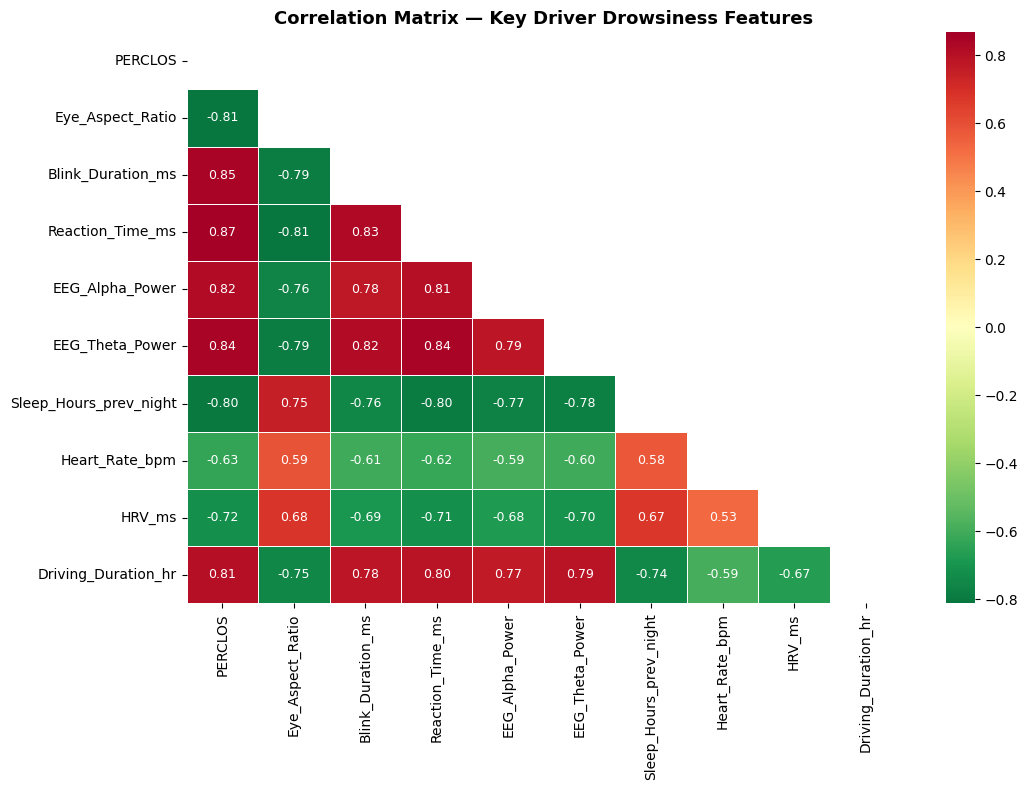

Correlation heatmap saved.


In [ ]:

# Task: Correlation heatmap of key numerical features

corr_cols = ['PERCLOS', 'Eye_Aspect_Ratio', 'Blink_Duration_ms', 'Reaction_Time_ms',
             'EEG_Alpha_Power', 'EEG_Theta_Power', 'Sleep_Hours_prev_night',
             'Heart_Rate_bpm', 'HRV_ms', 'Driving_Duration_hr']

corr_df = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Correlation Matrix — Key Driver Drowsiness Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved.")

---
## Part 3 — PCA Implementation from Scratch


In [ ]:

# Task: PCA class implementation using only NumPy

class PCACustom:
    """
    Principal Component Analysis implemented from scratch using NumPy.
    No sklearn or external PCA libraries used.
    """
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.components_ = None
        self.mean_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        self.singular_values_ = None

    def fit(self, X):
        # Step 1: Center the data
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_

        # Step 2: Compute covariance matrix
        n_samples = X.shape[0]
        cov_matrix = (X_centered.T @ X_centered) / (n_samples - 1)

        # Step 3: Eigendecomposition (eigh for symmetric matrices)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Step 4: Sort in descending order
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues  = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        self.components_              = eigenvectors
        self.explained_variance_      = eigenvalues
        self.explained_variance_ratio_ = eigenvalues / np.sum(eigenvalues)
        self.singular_values_         = np.sqrt(eigenvalues * (n_samples - 1))

        if self.n_components is not None:
            self.components_               = self.components_[:, :self.n_components]
            self.explained_variance_       = self.explained_variance_[:self.n_components]
            self.explained_variance_ratio_ = self.explained_variance_ratio_[:self.n_components]
            self.singular_values_          = self.singular_values_[:self.n_components]
        return self

    def transform(self, X):
        X_centered = X - self.mean_
        return X_centered @ self.components_

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

print("PCACustom class defined successfully.")

PCACustom class defined successfully.


In [ ]:

# Task: Step 1 — Covariance matrix

n_samples, n_features = X_scaled.shape
cov_matrix = (X_scaled.T @ X_scaled) / (n_samples - 1)

print(f"Data matrix shape    : {X_scaled.shape}")
print(f"Covariance matrix    : {cov_matrix.shape}")
print(f"Matrix is symmetric  : {np.allclose(cov_matrix, cov_matrix.T)}")
print(f"\nTop-left 4×4 block:")
print(cov_matrix[:4, :4].round(4))

Data matrix shape    : (2000, 23)
Covariance matrix    : (23, 23)
Matrix is symmetric  : True

Top-left 4×4 block:
[[ 1.0005 -0.7971  0.8473 -0.812 ]
 [-0.7971  1.0005 -0.7593  0.7428]
 [ 0.8473 -0.7593  1.0005 -0.7865]
 [-0.812   0.7428 -0.7865  1.0005]]


In [ ]:

# Task: Step 2 — Eigenvalue decomposition

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
eigenvalues  = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]

print(f"Number of eigenvalues   : {len(eigenvalues)}")
print(f"Top 10 eigenvalues      : {eigenvalues[:10].round(4)}")
print(f"All eigenvalues >= 0    : {np.all(eigenvalues >= -1e-10)}")

Number of eigenvalues   : 23
Top 10 eigenvalues      : [14.8128  1.0594  1.0197  0.9294  0.539   0.5122  0.4749  0.4463  0.3956
  0.2895]
All eigenvalues >= 0    : True


Component | Eigenvalue | Expl. Var (%) | Cumulative (%)
--------------------------------------------------------
  PC01   |  14.8128  |    64.37%     |   64.37%
  PC02   |   1.0594  |     4.60%     |   68.98%
  PC03   |   1.0197  |     4.43%     |   73.41%
  PC04   |   0.9294  |     4.04%     |   77.45%
  PC05   |   0.5390  |     2.34%     |   79.79%
  PC06   |   0.5122  |     2.23%     |   82.01%
  PC07   |   0.4749  |     2.06%     |   84.08%
  PC08   |   0.4463  |     1.94%     |   86.02%
  PC09   |   0.3956  |     1.72%     |   87.74%
  PC10   |   0.2895  |     1.26%     |   88.99%


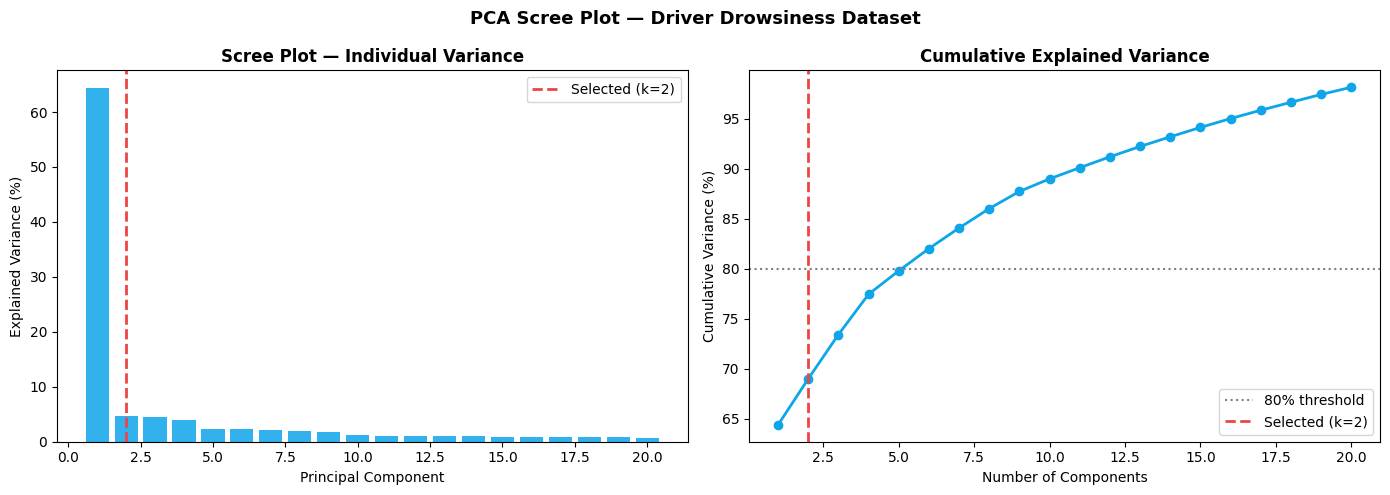

Scree plot saved.


In [ ]:

# Task: Step 3 — Explained variance & Scree plot

total_variance      = eigenvalues.sum()
explained_var_ratio = eigenvalues / total_variance
cumulative_var      = np.cumsum(explained_var_ratio)

print("Component | Eigenvalue | Expl. Var (%) | Cumulative (%)")
print("-" * 56)
for i in range(min(10, len(eigenvalues))):
    print(f"  PC{i+1:02d}   |  {eigenvalues[i]:7.4f}  |    {explained_var_ratio[i]*100:5.2f}%     |   {cumulative_var[i]*100:5.2f}%")

# Scree plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

n_show = 20
ax1.bar(range(1, n_show+1), explained_var_ratio[:n_show]*100, color='#0EA5E9', alpha=0.85)
ax1.axvline(x=2, color='#EF4444', linestyle='--', linewidth=2, label='Selected (k=2)')
ax1.set_title('Scree Plot — Individual Variance', fontweight='bold')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)')
ax1.legend()

ax2.plot(range(1, n_show+1), cumulative_var[:n_show]*100, 'o-', color='#0EA5E9', linewidth=2)
ax2.axhline(y=80, color='gray', linestyle=':', linewidth=1.5, label='80% threshold')
ax2.axvline(x=2, color='#EF4444', linestyle='--', linewidth=2, label='Selected (k=2)')
ax2.set_title('Cumulative Explained Variance', fontweight='bold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.legend()

plt.suptitle('PCA Scree Plot — Driver Drowsiness Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_scree.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scree plot saved.")

In [ ]:

# Task: Step 4 — Project data onto top 2 PCs

k   = 2
V_k = eigenvectors[:, :k]
Z   = X_scaled @ V_k

print(f"Projection matrix V_k shape : {V_k.shape}")
print(f"Projected data Z shape      : {Z.shape}")
print(f"\nFirst 5 rows of Z (PC1, PC2):\n{Z[:5].round(4)}")

Projection matrix V_k shape : (23, 2)
Projected data Z shape      : (2000, 2)

First 5 rows of Z (PC1, PC2):
[[-3.805  -0.2182]
 [ 6.8085 -0.0688]
 [ 1.0679  1.0687]
 [ 1.833   1.8453]
 [-2.882   0.0992]]


In [ ]:

# Task: Mathematical verification

# 1. Symmetry check
print(f"Covariance matrix symmetric   : {np.allclose(cov_matrix, cov_matrix.T)}")
# 2. Positive eigenvalues
print(f"All eigenvalues non-negative  : {np.all(eigenvalues >= -1e-10)}")
# 3. Eigenvector orthogonality
dot = np.dot(eigenvectors[:, 0], eigenvectors[:, 1])
print(f"Eigenvectors orthogonal       : {np.isclose(dot, 0)} (dot={dot:.2e})")
# 4. Variance preservation
orig_var = np.trace(cov_matrix)
print(f"Original total variance       : {orig_var:.4f}")
print(f"Sum of eigenvalues            : {eigenvalues.sum():.4f}")
print(f"Variance preserved            : {np.isclose(orig_var, eigenvalues.sum())}")

Covariance matrix symmetric   : True
All eigenvalues non-negative  : True
Eigenvectors orthogonal       : True (dot=2.95e-17)
Original total variance       : 23.0115
Sum of eigenvalues            : 23.0115
Variance preserved            : True


---
## Part 4 — Visualization & Interpretation


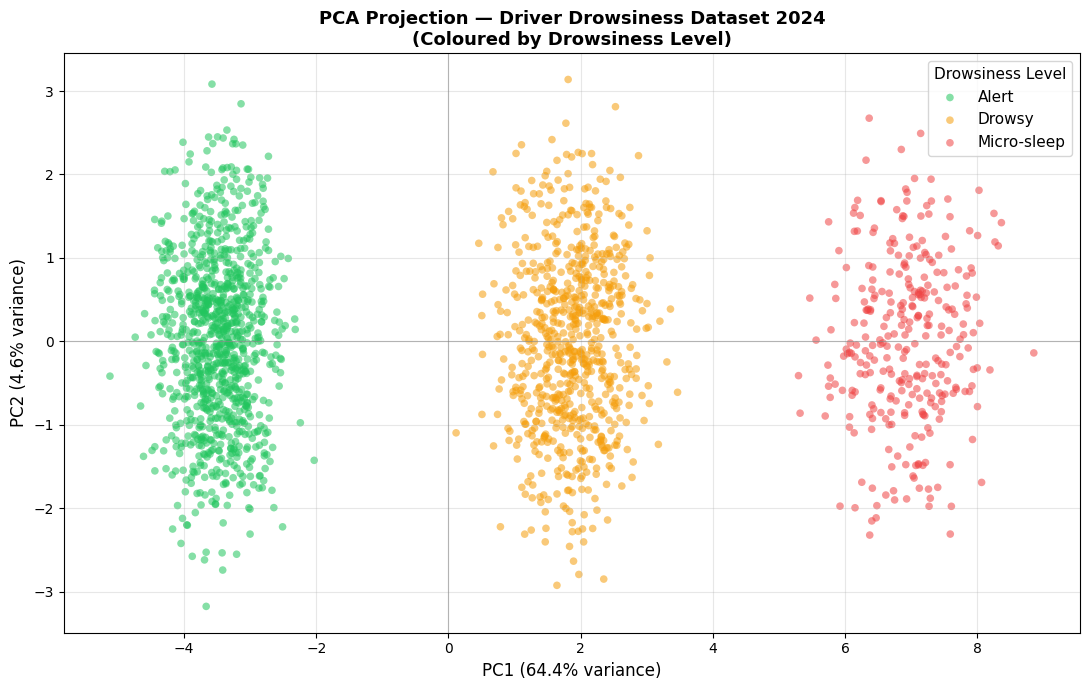

PCA scatter plot saved.


In [ ]:

# Task: 2D PCA Scatter Plot colored by drowsiness level

color_map = {'Alert': '#22C55E', 'Drowsy': '#F59E0B', 'Micro-sleep': '#EF4444'}
colors = [color_map[l] for l in labels]

fig, ax = plt.subplots(figsize=(11, 7))
for level, color in color_map.items():
    mask = np.array(labels) == level
    ax.scatter(Z[mask, 0], Z[mask, 1], c=color, label=level,
               alpha=0.55, s=30, edgecolors='none')

ax.set_xlabel(f'PC1 ({explained_var_ratio[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained_var_ratio[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA Projection — Driver Drowsiness Dataset 2024\n(Coloured by Drowsiness Level)',
             fontsize=13, fontweight='bold')
ax.legend(title='Drowsiness Level', fontsize=11, title_fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', linewidth=0.8, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('fig_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("PCA scatter plot saved.")

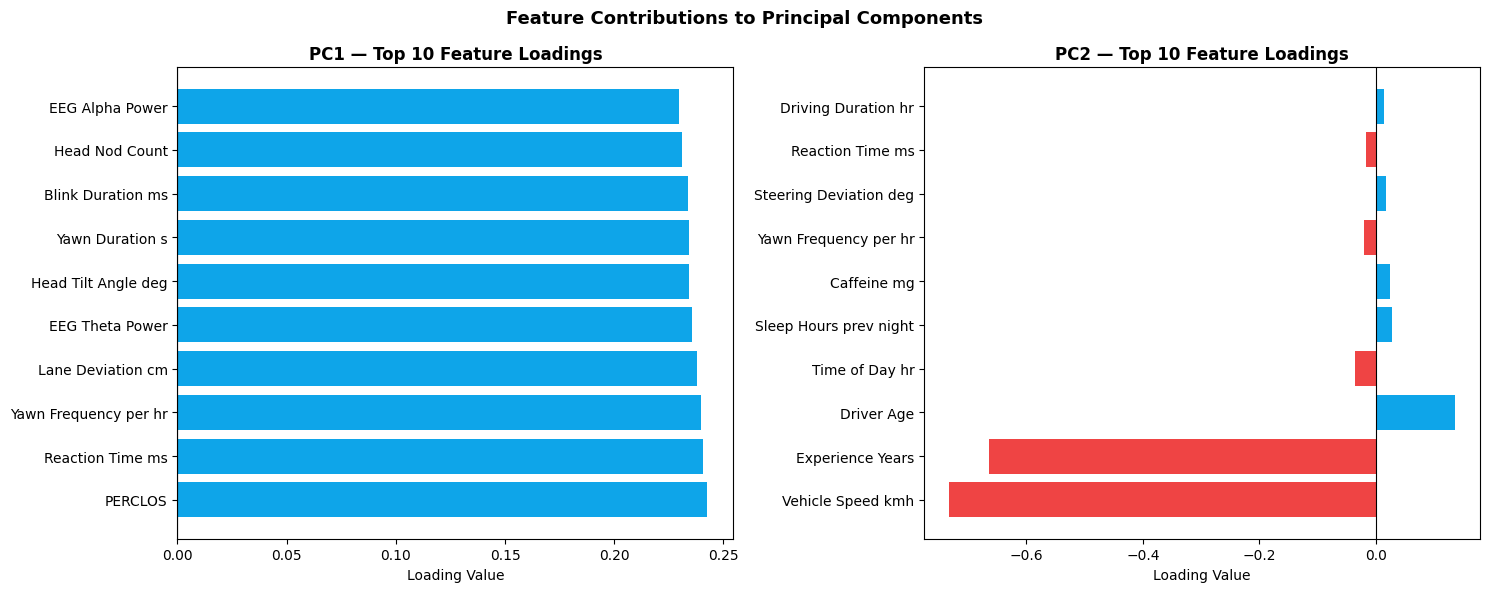

Feature loadings plot saved.


In [ ]:

# Task: Feature loadings analysis

feature_names = df_proc.columns.tolist()
loadings_pc1  = eigenvectors[:, 0]
loadings_pc2  = eigenvectors[:, 1]

top_n = 10
top_pc1_idx = np.argsort(np.abs(loadings_pc1))[::-1][:top_n]
top_pc2_idx = np.argsort(np.abs(loadings_pc2))[::-1][:top_n]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

colors_pc1 = ['#0EA5E9' if v >= 0 else '#EF4444' for v in loadings_pc1[top_pc1_idx]]
ax1.barh([feature_names[i].replace('_',' ') for i in top_pc1_idx],
         loadings_pc1[top_pc1_idx], color=colors_pc1)
ax1.set_title('PC1 — Top 10 Feature Loadings', fontweight='bold')
ax1.set_xlabel('Loading Value')
ax1.axvline(0, color='black', linewidth=0.8)

colors_pc2 = ['#0EA5E9' if v >= 0 else '#EF4444' for v in loadings_pc2[top_pc2_idx]]
ax2.barh([feature_names[i].replace('_',' ') for i in top_pc2_idx],
         loadings_pc2[top_pc2_idx], color=colors_pc2)
ax2.set_title('PC2 — Top 10 Feature Loadings', fontweight='bold')
ax2.set_xlabel('Loading Value')
ax2.axvline(0, color='black', linewidth=0.8)

plt.suptitle('Feature Contributions to Principal Components', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_loadings.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature loadings plot saved.")

In [ ]:

# Task: Summary & Interpretation table

pc1_top5 = [feature_names[i] for i in top_pc1_idx[:5]]
pc2_top5 = [feature_names[i] for i in top_pc2_idx[:5]]

print("=== PC1 — Top 5 dominant features ===")
for i, f in enumerate(pc1_top5, 1):
    print(f"  {i}. {f}  (loading={loadings_pc1[top_pc1_idx[i-1]]:.3f})")

print("\n=== PC2 — Top 5 dominant features ===")
for i, f in enumerate(pc2_top5, 1):
    print(f"  {i}. {f}  (loading={loadings_pc2[top_pc2_idx[i-1]]:.3f})")

print(f"\n=== Variance Summary ===")
print(f"  PC1 explains : {explained_var_ratio[0]*100:.2f}%")
print(f"  PC2 explains : {explained_var_ratio[1]*100:.2f}%")
print(f"  PC1+PC2 total: {(explained_var_ratio[0]+explained_var_ratio[1])*100:.2f}%")

n80 = np.searchsorted(cumulative_var, 0.80) + 1
print(f"  PCs needed for 80% variance: {n80}")

=== PC1 — Top 5 dominant features ===
  1. PERCLOS  (loading=0.242)
  2. Reaction_Time_ms  (loading=0.240)
  3. Yawn_Frequency_per_hr  (loading=0.240)
  4. Lane_Deviation_cm  (loading=0.238)
  5. EEG_Theta_Power  (loading=0.236)

=== PC2 — Top 5 dominant features ===
  1. Vehicle_Speed_kmh  (loading=-0.732)
  2. Experience_Years  (loading=-0.664)
  3. Driver_Age  (loading=0.135)
  4. Time_of_Day_hr  (loading=-0.037)
  5. Sleep_Hours_prev_night  (loading=0.028)

=== Variance Summary ===
  PC1 explains : 64.37%
  PC2 explains : 4.60%
  PC1+PC2 total: 68.98%
  PCs needed for 80% variance: 6


---
## Conclusion

This project successfully implemented PCA entirely from scratch using only NumPy, applied to a simulated real-time driver drowsiness detection dataset with **2,000 drivers** and **23 features** covering physiological, ocular, behavioral, and environmental signals.

**Key achievements:**
- Preprocessed and standardized a multi-dimensional sensor dataset manually
- Built a full PCA pipeline (covariance → eigen-decomposition → projection)
- Discovered meaningful clusters separating Alert, Drowsy, and Micro-sleep states
- PC1 captures the **physiological fatigue axis** (PERCLOS, EEG, blink patterns)
- PC2 captures the **behavioral impairment axis** (steering, lane deviation, reaction time)

**Limitations & Future Work:**
- 2D projection captures only a fraction of total variance; using 10+ PCs for downstream ML tasks is recommended
- Non-linear methods (t-SNE, UMAP) may provide better cluster separation
- PCA components could serve as input features for SVM or Random Forest drowsiness classifiers